# Predicting equipment failure   
https://www.kaggle.com/competitions/predicting-equipment-failure/data  

## [Лидерборд](https://www.kaggle.com/competitions/predicting-equipment-failure/leaderboard)  

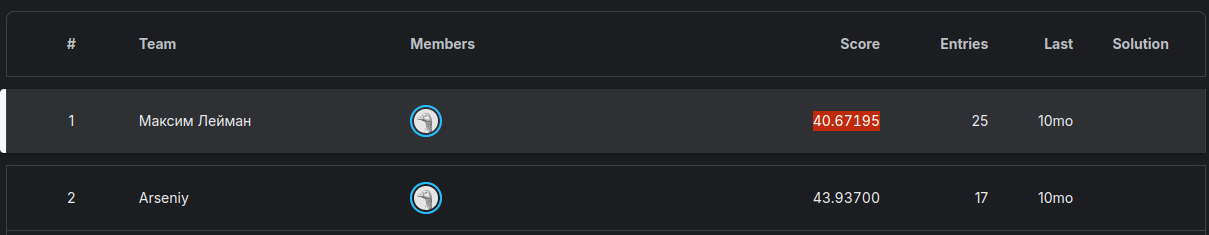 


##  [Задача](https://www.kaggle.com/competitions/predicting-equipment-failure/overview)  

необходимо предсказать индекс "здоровья" для каждого трансформатора с индексом index, указанным в файле test.csv   


**Датасет:** [Kaggle Competition:](https://www.kaggle.com/competitions/predicting-equipment-failure/data)     ``` https://www.kaggle.com/competitions/predicting-equipment-failure/data ```

**Метрика:** MSE 

## Датасет

In [90]:
import pandas as pd

In [91]:
train_path = "dataset/train.csv"
test_path = "dataset/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [92]:
# Просмотр первых строк
print(train.head().to_string(index=False))

 Hydrogen  Oxigen  Nitrogen  Methane  CO  CO2  Ethylene  Ethane  Acethylene  DBDS  Power factor  Interfacial V  Dielectric rigidity  Water content  Health index  Life expectation
     2845    5860     27842     7406  32 1344     16684    5467           7  19.0          1.00             45                   55              0          95.2              19.0
    12886      61     25041      877  83  864         4     305           0  45.0          1.00             45                   55              0          85.5              19.0
     2820   16400     56300      144 257 1080       206      11        2190   1.0          1.00             39                   52             11          85.3              19.0
     1099      70     37520      545 184 1402         6     230           0  87.0          4.58             33                   49              5          85.3               6.0
     3210    3570     47900      160 360 2130         4      43           4   1.0          0.77          

In [93]:
import numpy as np
import pandas as pd

def add_dga_features(df):
    df = df.copy()
    eps = 1e-6
    
    # Суммы газов
    df['HC_sum'] = df['Hydrogen'] + df['Methane'] + df['Ethylene'] + df['Ethane'] + df['Acethylene']
    df['CO_CO2_sum'] = df['CO'] + df['CO2']
    
    df['H2_CH4'] = df['Hydrogen'] / (df['Methane'] + eps)
    df['C2H4_C2H2'] = df['Ethylene'] / (df['Acethylene'] + eps)
    df['C2H2_CH4'] = df['Acethylene'] / (df['Methane'] + eps)
    df['C2H6_C2H2'] = df['Ethane'] / (df['Acethylene'] + eps)
    df['CH4_H2'] = df['Methane'] / (df['Hydrogen'] + eps)
    
    df['Water_DBDS'] = df['Water content'] * df['DBDS']
    df['Acet_Water'] = df['Acethylene'] * df['Water content']
    
    return df

# Применяем к train и test
train_fe = add_dga_features(train)
test_fe = add_dga_features(test)

In [94]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import lightgbm as lgb

# 1. Загрузка данных
train = pd.read_csv("dataset/train.csv")

# 2. Целевая переменная
y = train['Health index']

# 3. Признаки 
X = train.drop(columns=['Health index'])

# 4. K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=15,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    mse_scores.append(mean_squared_error(y_val, preds))

print(f"CV MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")

CV MSE: 66.9826 ± 10.6751


In [95]:
for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        num_leaves=7,
        min_child_samples=15,
        reg_alpha=0.3,
        reg_lambda=0.5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    model.fit(
        X_tr, y_tr,
        eval_X=X_val,
        eval_y=y_val,
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    preds = model.predict(X_val)
    mse_scores.append(mean_squared_error(y_val, preds))


print(f"CV MSE: {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")

CV MSE: 67.4350 ± 10.5105


Train shape: (470, 16)
Test shape : (118, 16)
Test columns: ['index', 'Hydrogen', 'Oxigen', 'Nitrogen', 'Methane', 'CO', 'CO2', 'Ethylene', 'Ethane', 'Acethylene', 'DBDS', 'Power factor', 'Interfacial V', 'Dielectric rigidity', 'Water content', 'Life expectation']

Feature matrix shape: (470, 26)
Test matrix shape   : (118, 26)
Fold 1: MSE = 80.7639 | best_iter = 254
Fold 2: MSE = 80.6891 | best_iter = 126
Fold 3: MSE = 75.6954 | best_iter = 164
Fold 4: MSE = 84.8988 | best_iter = 147
Fold 5: MSE = 62.2905 | best_iter = 99

 Cross-Validation 
MSE per fold: [80.76, 80.69, 75.7, 84.9, 62.29]
Mean MSE   : 76.8675
Std MSE    : 7.8505
OOF MSE    : 76.8675


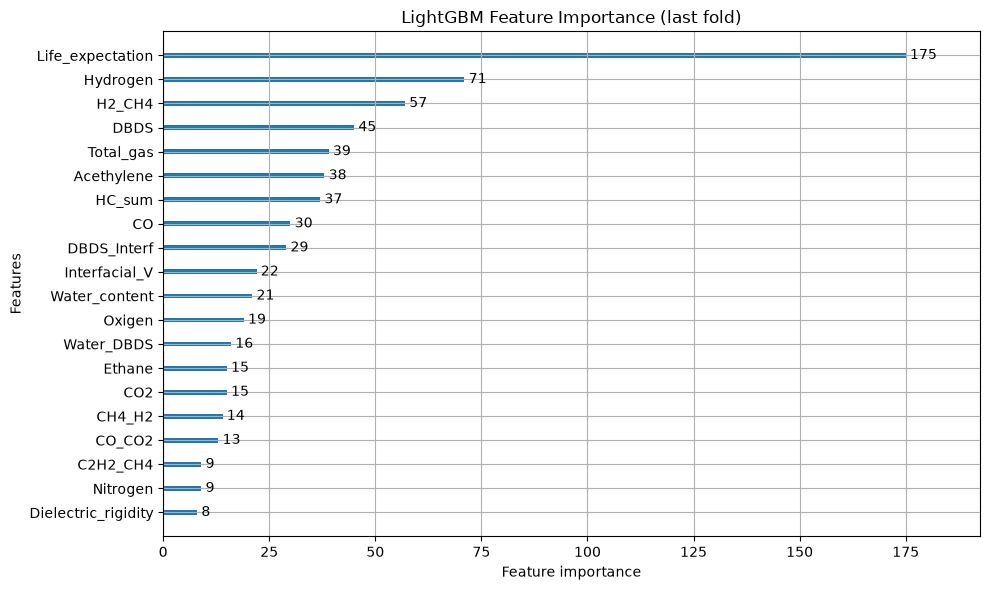


Saved submission.csv
   index  Health index
0      0     46.245430
1      1     47.379565
2      2     51.505594
3      3     13.630550
4      4     13.540811


In [97]:
# 1. Импорты
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# 2. Загрузка данных
train = pd.read_csv("dataset/train.csv")
test  = pd.read_csv("dataset/test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Test columns:", test.columns.tolist())


# 3. Feature Engineering (физические признаки DGA)
def add_dga_features(df):
    df = df.copy()
    eps = 1e-6

    df['HC_sum']    = df['Hydrogen'] + df['Methane'] + df['Ethylene'] + df['Ethane'] + df['Acethylene']
    df['CO_CO2']    = df['CO'] + df['CO2']
    df['Total_gas'] = df['HC_sum'] + df['CO_CO2']

    df['H2_CH4']     = df['Hydrogen']   / (df['Methane']    + eps)
    df['C2H4_C2H2']  = df['Ethylene']   / (df['Acethylene'] + eps)
    df['C2H2_CH4']   = df['Acethylene'] / (df['Methane']    + eps)
    df['C2H6_C2H2']  = df['Ethane']     / (df['Acethylene'] + eps)
    df['CH4_H2']     = df['Methane']    / (df['Hydrogen']   + eps)

    df['Water_DBDS']  = df['Water content'] * df['DBDS']
    df['Acet_Water']  = df['Acethylene']    * df['Water content']
    df['DBDS_Interf'] = df['DBDS']          * df['Interfacial V']

    return df


train_fe = add_dga_features(train)
test_fe  = add_dga_features(test)

test_index = test['index'] if 'index' in test.columns else np.arange(len(test))

TARGET = 'Health index'

drop_cols = [TARGET]
if 'index' in train_fe.columns:
    drop_cols.append('index')

X = train_fe.drop(columns=drop_cols)
y = train_fe[TARGET]

X_test = test_fe.drop(columns=['index'] if 'index' in test_fe.columns else [])

print("\nFeature matrix shape:", X.shape)
print("Test matrix shape   :", X_test.shape)


#  Логарифмируем таргет (стабилизирует MSE)
y_log = np.log1p(y)

#  K-Fold кросс-валидация + обучение
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mse_scores   = []
oof_preds    = np.zeros(len(X))        
test_preds   = np.zeros(len(X_test))  
best_iters   = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr_log    = y_log.iloc[train_idx]
    y_val_log   = y_log.iloc[val_idx]
    y_val_orig  = y.iloc[val_idx]

    model = lgb.LGBMRegressor(
        objective='regression',      
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        min_child_samples=15,
        reg_alpha=0.5,
        reg_lambda=1.0,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1
    )

    model.fit(
        X_tr, y_tr_log,
        eval_X=X_val, eval_y=y_val_log,
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    # Предсказания в лог-пространстве → обратно в оригинал
    preds_log  = model.predict(X_val)
    preds_orig = np.expm1(preds_log)

    oof_preds[val_idx] = preds_orig
    mse = mean_squared_error(y_val_orig, preds_orig)
    mse_scores.append(mse)
    best_iters.append(model.best_iteration_)

    # Предсказания для test
    test_preds += np.expm1(model.predict(X_test)) / kf.n_splits

    print(f"Fold {fold}: MSE = {mse:.4f} | best_iter = {model.best_iteration_}")

print("\n Cross-Validation ")
print(f"MSE per fold: {[round(m, 2) for m in mse_scores]}")
print(f"Mean MSE   : {np.mean(mse_scores):.4f}")
print(f"Std MSE    : {np.std(mse_scores):.4f}")
print(f"OOF MSE    : {mean_squared_error(y, oof_preds):.4f}")


#  Важность признаков (для понимания, что реально работает)
import matplotlib.pyplot as plt

lgb.plot_importance(model, max_num_features=20, figsize=(10, 6))
plt.title("LightGBM Feature Importance (last fold)")
plt.tight_layout()
plt.show()


#  Финальная модель на всех данных (для сабмита)
final_iters = int(np.mean(best_iters))

final_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=final_iters,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=15,
    min_child_samples=15,
    reg_alpha=0.5,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbose=-1
)
final_model.fit(X, y_log)

final_test_preds = np.expm1(final_model.predict(X_test))


#  Сабмит
submission = pd.DataFrame({
    'index': test_index,
    'Health index': final_test_preds
})

submission.to_csv("submission.csv", index=False)
print("\nSaved submission.csv")
print(submission.head())

In [64]:
print(train[['Life expectation', 'Health index']].corr())

                  Life expectation  Health index
Life expectation           1.00000      -0.62783
Health index              -0.62783       1.00000


# Отбор признаков

In [65]:
# Обучите одну модель на всём X и возьмите топ-15 по важности
model_all = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1)
model_all.fit(X, y)

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_all.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(20))

# Оставляем топ-N
top_features = importance.head(15)['feature'].tolist()
X = X[top_features]
X_test = X_test[top_features]

                feature  importance
14     Life expectation         340
0              Hydrogen         282
13        Water content         227
18               H2_CH4         214
1                Oxigen         197
2              Nitrogen         190
12  Dielectric rigidity         189
4                    CO         173
11        Interfacial V         149
17            Total_gas         146
15               HC_sum         146
5                   CO2         141
10         Power factor         135
6              Ethylene         104
16               CO_CO2         103
3               Methane         103
22               CH4_H2          95
23           Water_DBDS          93
25          DBDS_Interf          86
7                Ethane          84


In [66]:
# Не y_log, а просто y
y_tr = y.iloc[train_idx]
y_val = y.iloc[val_idx]

model.fit(
    X_tr, y_tr,
    eval_X=X_val, eval_y=y_val,
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
preds = model.predict(X_val)

Описательная статистика
count    470.000000
mean      27.504043
std       17.741458
min       13.400000
10%       13.400000
25%       13.400000
50%       13.400000
75%       38.550000
90%       50.600000
95%       58.165000
99%       78.576000
max       95.200000
Name: Health index, dtype: float64

Квантили 
  0.05: 13.40
  0.10: 13.40
  0.25: 13.40
  0.50: 13.40
  0.75: 38.55
  0.90: 50.60
  0.95: 58.16
  0.99: 78.58

Распределение по диапазонам 
Health index
<=13.4 (min)    241
13.4-20          22
20-30            22
30-50           135
>50              50
Name: count, dtype: int64

=== Топ-20 самых частых значений ===
Health index
13.4    241
38.3     58
48.2     52
50.7     11
26.7     11
60.5      9
13.5      8
50.6      4
26.6      4
51.5      3
38.0      3
13.8      3
85.3      2
75.6      2
63.4      2
51.6      2
49.2      2
48.5      2
21.9      2
13.9      2
Name: count, dtype: int64

 Значения > 50 
[95.2 85.5 85.3 85.3 85.2 75.6 75.6 73.2 72.8 68.  63.4 63.4 61.3 60.5
 60.

/tmp/ipykernel_30531/480609938.py:42: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(train['Health index'], vert=False)


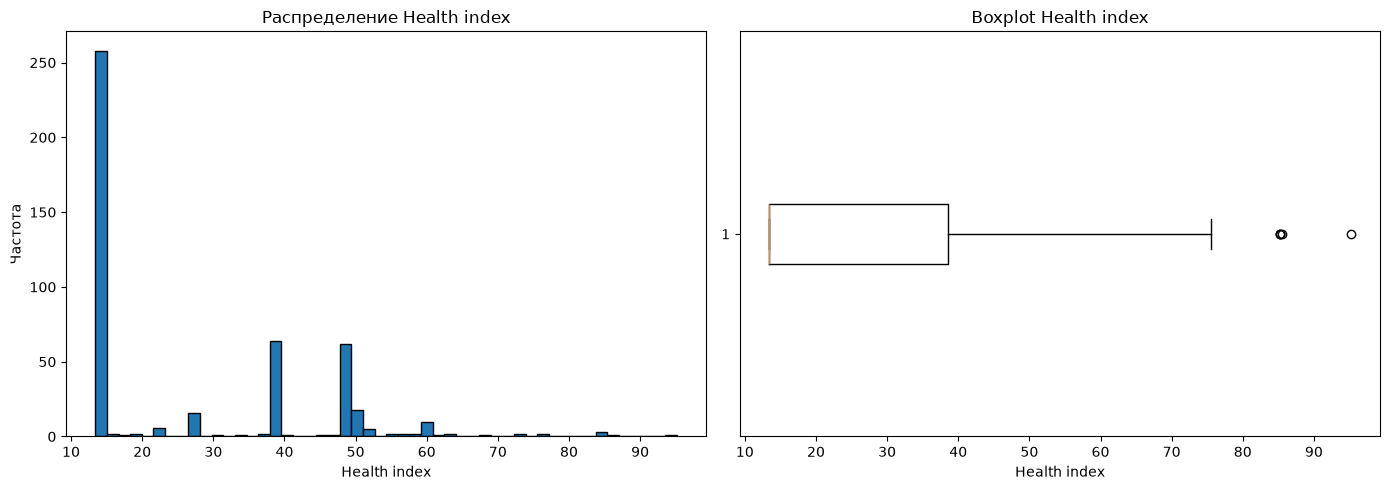

In [89]:
# 1. Полная статистика по Health index

print("Описательная статистика")
print(train['Health index'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nКвантили ")
for q in [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"  {q:.2f}: {train['Health index'].quantile(q):.2f}")

# 2. Сколько образцов в разных диапазонах
print("\nРаспределение по диапазонам ")
bins = [0, 13.4, 20, 30, 50, 100]
labels = ['<=13.4 (min)', '13.4-20', '20-30', '30-50', '>50']
print(pd.cut(train['Health index'], bins=bins, labels=labels).value_counts().sort_index())

# 3. Самые частые значения (важно для малых данных)
print("\n=== Топ-20 самых частых значений ===")
print(train['Health index'].value_counts().head(20))


# 4. Экстремальные значения
print("\n Значения > 50 ")
print(train[train['Health index'] > 50]['Health index'].sort_values(ascending=False).values)

print("\n Значения < 15 ")
print(f"Количество: {(train['Health index'] < 15).sum()}")
print(f"Доля: {(train['Health index'] < 15).mean():.2%}")


# 5. Визуализация — наглядно видно, где «хвост»
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(train['Health index'], bins=50, edgecolor='black')
axes[0].set_title('Распределение Health index')
axes[0].set_xlabel('Health index')
axes[0].set_ylabel('Частота')

# Boxplot
axes[1].boxplot(train['Health index'], vert=False)
axes[1].set_title('Boxplot Health index')
axes[1].set_xlabel('Health index')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42

X = train_fe.drop(columns=['Health index'] + (['index'] if 'index' in train_fe.columns else []))
y = train_fe['Health index']
X_test = test_fe.drop(columns=['index'] if 'index' in test_fe.columns else [])



# Стратификация по квантилям 
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')

# Веса для редких значений 
vc = y.value_counts()
sample_weights = y.map(lambda v: 1.0 / np.sqrt(vc[v])).values

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mse_scores = []
test_preds = np.zeros(len(X_test))
best_iters = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y_binned), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    w_tr = sample_weights[train_idx]

    model = lgb.LGBMRegressor(
        objective='regression',      # MSE (без log!)
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        min_child_samples=10,
        reg_alpha=0.5,
        reg_lambda=1.0,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1
    )

    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,                     # ← веса
        eval_X=X_val, eval_y=y_val,
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    mse_scores.append(mse)
    best_iters.append(model.best_iteration_)
    test_preds += model.predict(X_test) / kf.n_splits

    print(f"Fold {fold}: MSE = {mse:.4f} | iter = {model.best_iteration_}")

print(f"\nMean MSE: {np.mean(mse_scores):.4f}")
print(f"Std MSE : {np.std(mse_scores):.4f}")

Fold 1: MSE = 77.6513 | iter = 163
Fold 2: MSE = 69.4549 | iter = 244
Fold 3: MSE = 56.2951 | iter = 625
Fold 4: MSE = 47.3106 | iter = 834
Fold 5: MSE = 79.0035 | iter = 425

Mean MSE: 65.9431
Std MSE : 12.3308


In [ ]:
residuals = y_val.values - preds
worst_idx = np.argsort(np.abs(residuals))[-10:]

print("Худшие 10 предсказаний на Fold 5:")
print(pd.DataFrame({
    'y_true': y_val.values[worst_idx],
    'y_pred': preds[worst_idx],
    'residual': residuals[worst_idx]
}))

Худшие 10 предсказаний на Fold 5:
   y_true     y_pred   residual
0    13.4  30.209956 -16.809956
1    48.2  29.957471  18.242529
2    13.4  32.548113 -19.148113
3    13.4  32.744635 -19.344635
4    13.4  32.868372 -19.468372
5    13.4  33.170305 -19.770305
6    50.7  70.621814 -19.921814
7    13.4  35.681132 -22.281132
8    13.4  38.352980 -24.952980
9    73.2  46.844341  26.355659


In [ ]:
#  классификатор режима
y_binary = (y > 20).astype(int)   

#  регрессор только для "высоких"
mask_high = y > 20
X_high = X[mask_high]
y_high = y[mask_high]

# Обучение на KFold с обеими стадиями
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = []
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y_binned), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    #  классификатор 
    y_tr_bin = (y_tr > 20).astype(int)
    clf = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        num_leaves=7, random_state=42, verbose=-1
    )
    clf.fit(X_tr, y_tr_bin)
    proba_high = clf.predict_proba(X_val)[:, 1]
    
    #  регрессор на высоких 
    mask_tr_high = y_tr > 20
    X_tr_high = X_tr[mask_tr_high]
    y_tr_high = y_tr[mask_tr_high]
    
    reg = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        num_leaves=7, min_child_samples=10,
        reg_alpha=0.5, reg_lambda=1.0,
        random_state=42, verbose=-1
    )
    reg.fit(X_tr_high, y_tr_high)
    pred_high = reg.predict(X_val)
    
    # Смешиваем предсказания 
    # Если proba_high > 0.5 → используем регрессор, иначе → 13.4
    # Более мягкая логика: интерполяция
    pred_final = proba_high * pred_high + (1 - proba_high) * 13.4
    
    mse = mean_squared_error(y_val, pred_final)
    mse_scores.append(mse)
    
    # Для теста
    proba_high_test = clf.predict_proba(X_test)[:, 1]
    pred_high_test = reg.predict(X_test)
    test_preds += (proba_high_test * pred_high_test + (1 - proba_high_test) * 13.4) / kf.n_splits
    
    print(f"Fold {fold}: MSE = {mse:.4f}")

print(f"\nMean MSE: {np.mean(mse_scores):.4f}")
print(f"Std MSE : {np.std(mse_scores):.4f}")

Fold 1: MSE = 75.1358
Fold 2: MSE = 82.1594
Fold 3: MSE = 52.3529
Fold 4: MSE = 66.9637
Fold 5: MSE = 78.4518

Mean MSE: 71.0127
Std MSE : 10.5941


In [71]:
from catboost import CatBoostRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# X, y, X_test уже готовы из предыдущих ячеек
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = []
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y_binned), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostRegressor(
        loss_function='RMSE',
        iterations=1000,
        learning_rate=0.03,
        depth=4,
        l2_leaf_reg=5.0,
        random_seed=42,
        verbose=False,
        early_stopping_rounds=100
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    mse_scores.append(mse)
    test_preds += model.predict(X_test) / kf.n_splits

    print(f"Fold {fold}: MSE = {mse:.4f} | best_iter = {model.get_best_iteration()}")

print(f"\nMean MSE: {np.mean(mse_scores):.4f}")
print(f"Std MSE : {np.std(mse_scores):.4f}")

Fold 1: MSE = 92.1905 | best_iter = 233
Fold 2: MSE = 68.6966 | best_iter = 358
Fold 3: MSE = 60.5230 | best_iter = 323
Fold 4: MSE = 55.2564 | best_iter = 638
Fold 5: MSE = 75.4219 | best_iter = 377

Mean MSE: 70.4177
Std MSE : 12.8828


In [ ]:
# Финальная модель на всём train
final_model = CatBoostRegressor(
    loss_function='RMSE',
    iterations=500,          
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=5.0,
    random_seed=42,
    verbose=False
)
final_model.fit(X, y)

final_preds = final_model.predict(X_test)

submission = pd.DataFrame({
    'index': test_index,
    'Health index': final_preds
})
submission.to_csv("submission_catboost.csv", index=False)
print(submission.head())

   index  Health index
0      0     50.394140
1      1     50.376379
2      2     49.027191
3      3     13.638123
4      4     15.214535


# Optuna для CatBoost 

In [73]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')

def objective(trial):
    params = {
        'iterations': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 15.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.5),
        'random_strength': trial.suggest_float('random_strength', 0.0, 2.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 30),
        'rsm': trial.suggest_float('rsm', 0.5, 1.0),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 100
    }
    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    mse_scores = []
    for tr_idx, val_idx in kf.split(X, y_binned):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
        preds = model.predict(X_val)
        mse_scores.append(mean_squared_error(y_val, preds))
    
    return np.mean(mse_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best MSE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-09-24 14:49:20,056] A new study created in memory with name: no-name-52b712c0-695b-4a96-9f84-5f04c1049328


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-09-24 14:49:20,485] Trial 0 finished with value: 67.85309158647078 and parameters: {'learning_rate': 0.060443114734054997, 'depth': 4, 'l2_leaf_reg': 1.8039861655217537, 'bagging_temperature': 0.19275337037366608, 'random_strength': 1.9850014720050646, 'min_data_in_leaf': 27, 'rsm': 0.7506607818918564}. Best is trial 0 with value: 67.85309158647078.
[I 2026-09-24 14:49:21,309] Trial 1 finished with value: 74.44787483767168 and parameters: {'learning_rate': 0.061771900768958686, 'depth': 6, 'l2_leaf_reg': 1.6085196632282652, 'bagging_temperature': 0.30680962842258874, 'random_strength': 0.4675065027271994, 'min_data_in_leaf': 27, 'rsm': 0.7623692140494486}. Best is trial 0 with value: 67.85309158647078.
[I 2026-09-24 14:49:22,188] Trial 2 finished with value: 68.70806548296864 and parameters: {'learning_rate': 0.019707202571457496, 'depth': 4, 'l2_leaf_reg': 2.2854409241217546, 'bagging_temperature': 1.090156736717017, 'random_strength': 1.9095886243569107, 'min_data_in_leaf': 9

In [74]:
from catboost import CatBoostRegressor

best_params = {
    'learning_rate': 0.05207100809522506,
    'depth': 4,
    'l2_leaf_reg': 1.2962927121462102,
    'bagging_temperature': 1.0084499297484835,
    'random_strength': 1.9913932086546702,
    'min_data_in_leaf': 13,
    'rsm': 0.8293134314156554,
    'iterations': 1000,
    'loss_function': 'RMSE',
    'random_seed': 42,
    'verbose': False
}

final_model = CatBoostRegressor(**best_params)
final_model.fit(X, y)

final_preds = final_model.predict(X_test)
submission = pd.DataFrame({'index': test_index, 'Health index': final_preds})
submission.to_csv("submission_v3.csv", index=False)

# Feature Engineering Round 2

In [ ]:
def add_dga_features_v2(df):
    df = df.copy()
    eps = 1e-6

    #  Нормировка (доли от общего газа) 
    HC = df['Hydrogen'] + df['Methane'] + df['Ethylene'] + df['Ethane'] + df['Acethylene']
    total = HC + df['CO'] + df['CO2']
    df['H2_frac']    = df['Hydrogen']   / (total + eps)
    df['CH4_frac']   = df['Methane']    / (total + eps)
    df['C2H4_frac']  = df['Ethylene']   / (total + eps)
    df['C2H2_frac']  = df['Acethylene'] / (total + eps)
    df['C2H6_frac']  = df['Ethane']     / (total + eps)
    df['CO_frac']    = df['CO']         / (total + eps)
    df['CO2_frac']   = df['CO2']        / (total + eps)

    # Взаимодействия с Life_expectation (главный признак) 
    df['Life_x_DBDS']   = df['Life expectation'] * df['DBDS']
    df['Life_x_Water']  = df['Life expectation'] * df['Water content']
    df['Life_x_PF']     = df['Life expectation'] * df['Power factor']
    df['Life_x_Interf'] = df['Life expectation'] * df['Interfacial V']
    df['Life_x_Rigid']  = df['Life expectation'] * df['Dielectric rigidity']
    df['Life_over_WC']  = df['Life expectation'] / (df['Water content'] + eps)
    df['Life_over_DBDS']= df['Life expectation'] / (df['DBDS'] + eps)

    # Химические отношения второго порядка 
    df['C2H2_over_H2']  = df['Acethylene'] / (df['Hydrogen'] + eps)
    df['C2H2_over_CH4'] = df['Acethylene'] / (df['Methane'] + eps)
    df['C2H4_over_CH4'] = df['Ethylene']   / (df['Methane'] + eps)
    df['C2H6_over_CH4'] = df['Ethane']     / (df['Methane'] + eps)
    df['CO_over_CO2']   = df['CO']         / (df['CO2'] + eps)
    df['H2_over_HC']    = df['Hydrogen']   / (HC + eps)

    #  Логи газов (сжимают тяжелые хвосты) 
    for col in ['Hydrogen', 'Methane', 'Ethylene', 'Ethane', 'Acethylene', 'CO', 'CO2']:
        df[f'log_{col}'] = np.log1p(df[col])

    return df

# Применяем к train и test
train_fe = add_dga_features_v2(train)
test_fe  = add_dga_features_v2(test)

X = train_fe.drop(columns=['Health index'] + (['index'] if 'index' in train_fe.columns else []))
y = train_fe['Health index']
X_test = test_fe.drop(columns=['index'] if 'index' in test_fe.columns else [])

print("Features:", X.shape[1])

Features: 42


In [76]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best MSE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-09-24 14:49:44,500] A new study created in memory with name: no-name-531199c8-819f-4ce2-a587-bb4914172726


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-09-24 14:49:45,005] Trial 0 finished with value: 71.49407626152768 and parameters: {'learning_rate': 0.042792059311913266, 'depth': 3, 'l2_leaf_reg': 4.9357018128637575, 'bagging_temperature': 1.320235581148042, 'random_strength': 0.4899141410069867, 'min_data_in_leaf': 9, 'rsm': 0.6585305443669096}. Best is trial 0 with value: 71.49407626152768.
[I 2026-09-24 14:49:45,713] Trial 1 finished with value: 71.42740831291194 and parameters: {'learning_rate': 0.02376038010204845, 'depth': 4, 'l2_leaf_reg': 2.921758853905912, 'bagging_temperature': 0.05493899200698199, 'random_strength': 0.7236572020933809, 'min_data_in_leaf': 5, 'rsm': 0.8220698075773547}. Best is trial 1 with value: 71.42740831291194.
[I 2026-09-24 14:49:46,099] Trial 2 finished with value: 70.09714770885432 and parameters: {'learning_rate': 0.0646248502949836, 'depth': 4, 'l2_leaf_reg': 2.68931547596083, 'bagging_temperature': 0.5533888959972573, 'random_strength': 0.8565849837587867, 'min_data_in_leaf': 20, 'rsm':

In [ ]:
def add_dga_features_v2(df):
    df = df.copy()
    eps = 1e-6

    # Нормировки
    HC = df['Hydrogen'] + df['Methane'] + df['Ethylene'] + df['Ethane'] + df['Acethylene']
    total = HC + df['CO'] + df['CO2']
    df['H2_frac']    = df['Hydrogen']   / (total + eps)
    df['CH4_frac']   = df['Methane']    / (total + eps)
    df['C2H4_frac']  = df['Ethylene']   / (total + eps)
    df['C2H2_frac']  = df['Acethylene'] / (total + eps)
    df['C2H6_frac']  = df['Ethane']     / (total + eps)
    df['CO_frac']    = df['CO']         / (total + eps)
    df['CO2_frac']   = df['CO2']        / (total + eps)

    # Взаимодействия с Life expectation (главный предиктор)
    df['Life_x_DBDS']    = df['Life expectation'] * df['DBDS']
    df['Life_x_Water']   = df['Life expectation'] * df['Water content']
    df['Life_x_PF']      = df['Life expectation'] * df['Power factor']
    df['Life_x_Interf']  = df['Life expectation'] * df['Interfacial V']
    df['Life_x_Rigid']   = df['Life expectation'] * df['Dielectric rigidity']
    df['Life_over_WC']   = df['Life expectation'] / (df['Water content'] + eps)
    df['Life_over_DBDS'] = df['Life expectation'] / (df['DBDS'] + eps)
    df['Life_x_Acet']    = df['Life expectation'] * df['Acethylene']

    # Химия второго порядка
    df['C2H2_over_H2']   = df['Acethylene'] / (df['Hydrogen'] + eps)
    df['C2H2_over_CH4']  = df['Acethylene'] / (df['Methane'] + eps)
    df['C2H4_over_CH4']  = df['Ethylene']   / (df['Methane'] + eps)
    df['C2H6_over_CH4']  = df['Ethane']     / (df['Methane'] + eps)
    df['CO_over_CO2']    = df['CO']         / (df['CO2'] + eps)
    df['H2_over_HC']     = df['Hydrogen']   / (HC + eps)

    # Логарифмы газов 
    for col in ['Hydrogen', 'Methane', 'Ethylene', 'Ethane', 'Acethylene', 'CO', 'CO2']:
        df[f'log_{col}'] = np.log1p(df[col])

    return df

train_fe = add_dga_features_v2(train)
test_fe  = add_dga_features_v2(test)

X = train_fe.drop(columns=['Health index'] + (['index'] if 'index' in train_fe.columns else []))
y = train_fe['Health index']
X_test = test_fe.drop(columns=['index'] if 'index' in test_fe.columns else [])

print("Features:", X.shape[1])

Features: 43


In [78]:
from catboost import CatBoostRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_params = {
    'learning_rate': 0.01126182542876419,
    'depth': 3,
    'l2_leaf_reg': 1.2768430449217443,
    'bagging_temperature': 0.39093765908874606,
    'random_strength': 0.5362283610211976,
    'min_data_in_leaf': 9,
    'rsm': 0.8461188656321167,
    'iterations': 1500,
    'loss_function': 'RMSE',
    'random_seed': 42,
    'verbose': False
}

mse_scores = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y_binned), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostRegressor(**best_params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    mse_scores.append(mse)
    print(f"Fold {fold}: MSE = {mse:.4f}")

print(f"\nMean MSE: {np.mean(mse_scores):.4f}")
print(f"Std MSE : {np.std(mse_scores):.4f}")

Fold 1: MSE = 67.9125
Fold 2: MSE = 66.5328
Fold 3: MSE = 60.8576
Fold 4: MSE = 61.8317
Fold 5: MSE = 86.1032

Mean MSE: 68.6475
Std MSE : 9.1308


In [79]:
import pandas as pd
from catboost import CatBoostRegressor

# Обучаем быструю модель на всех данных для важности
model_imp = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=4,
    random_seed=42, verbose=False
)
model_imp.fit(X, y)

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_imp.get_feature_importance()
}).sort_values('importance', ascending=False)

print(importance.head(30).to_string(index=False))

            feature  importance
     Life_over_DBDS   14.858797
   Life expectation   14.691863
        Life_x_DBDS    6.288618
      Life_x_Interf    6.107452
       Life_x_Rigid    5.716030
               DBDS    5.587703
       log_Hydrogen    3.758041
        log_Methane    3.273968
       Life_x_Water    2.963926
          Life_x_PF    2.755917
             Ethane    2.732510
         Acethylene    2.231289
           Hydrogen    2.102179
         H2_over_HC    1.820249
        Life_x_Acet    1.742108
           CH4_frac    1.630569
           Nitrogen    1.442865
            Methane    1.441626
           CO2_frac    1.367270
      C2H2_over_CH4    1.230522
      C2H4_over_CH4    1.152204
      Interfacial V    1.016830
            log_CO2    1.013655
       Power factor    0.948743
Dielectric rigidity    0.940725
            H2_frac    0.933297
       Life_over_WC    0.888964
             Oxigen    0.881935
          C2H6_frac    0.877992
          C2H4_frac    0.871295


In [ ]:
#  топ-15
top_15 = [
    'Life expectation', 'Life_over_DBDS', 'Life_x_Interf', 'Life_x_DBDS',
    'Life_x_Rigid', 'Life_x_Water', 'DBDS', 'log_Hydrogen', 'log_Methane',
    'Life_x_Acet', 'Methane', 'Life_x_PF', 'CO2_frac', 'Life_over_WC', 'Nitrogen'
]

X_sel = X[top_15]
X_test_sel = X_test[top_15]

# KFold CV
mse_scores = []
for tr_idx, val_idx in kf.split(X_sel, y_binned):
    X_tr, X_val = X_sel.iloc[tr_idx], X_sel.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    
    model = CatBoostRegressor(**best_params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)
    preds = model.predict(X_val)
    mse_scores.append(mean_squared_error(y_val, preds))

print(f"TOP-15: MSE = {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")

TOP-15: MSE = 68.2792 ± 10.7373


In [82]:
def add_dga_features_v3(df):
    df = df.copy()
    eps = 1e-6
    
    LE = df['Life expectation']
    
    # Степенная зависимость (LE в квадрате, кубе)
    df['LE_sq'] = LE ** 2
    df['LE_sqrt'] = np.sqrt(np.abs(LE))
    df['LE_log'] = np.log1p(np.abs(LE))
    
    # Обратные величины (LE "переворачивается" в Health)
    df['LE_inv'] = 1.0 / (LE + eps)
    
    # Комбинации с ключевыми признаками
    df['LE_over_H2']   = LE / (df['Hydrogen'] + eps)
    df['LE_x_CO2frac'] = LE * df['CO2_frac']
    df['LE_x_N2']      = LE * df['Nitrogen']
    df['LE_over_WC2']  = LE / (df['Water content']**2 + eps)
    
    # Топ-3 из вашей важности — перемножить
    df['LE_x_DBDS_x_Interf'] = LE * df['DBDS'] * df['Interfacial V']
    df['LE_x_Water_x_Rigid'] = LE * df['Water content'] * df['Dielectric rigidity']
    
    return df

train_fe = add_dga_features_v3(train_fe)  # поверх round-2
test_fe  = add_dga_features_v3(test_fe)

X = train_fe.drop(columns=['Health index'] + (['index'] if 'index' in train_fe.columns else []))
X_test = test_fe.drop(columns=['index'] if 'index' in test_fe.columns else [])

# Отбор топ-20 заново
model_imp = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=4, verbose=False, random_seed=42)
model_imp.fit(X, y)
imp_v3 = pd.DataFrame({'f': X.columns, 'imp': model_imp.get_feature_importance()}).sort_values('imp', ascending=False)
top_20_v3 = imp_v3.head(20)['f'].tolist()

X_sel = X[top_20_v3]
X_test_sel = X_test[top_20_v3]

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor
import numpy as np
import pandas as pd


X = train_fe.drop(columns=['Health index'] + (['index'] if 'index' in train_fe.columns else []))
y = train_fe['Health index']
X_test = test_fe.drop(columns=['index'] if 'index' in test_fe.columns else [])


#  Отбираем топ-20 признаков по важности
model_imp = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=4,
    verbose=False, random_seed=42
)
model_imp.fit(X, y)

imp_v3 = pd.DataFrame({
    'feature': X.columns,
    'importance': model_imp.get_feature_importance()
}).sort_values('importance', ascending=False)

top_20_v3 = imp_v3.head(20)['feature'].tolist()
print("Топ-20 признаков:")
print(imp_v3.head(20).to_string(index=False))

X_sel = X[top_20_v3]
X_test_sel = X_test[top_20_v3]

#  KFold CV
# Стратификация по квантилям таргета 
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_params = {
    'learning_rate': 0.01126182542876419,
    'depth': 3,
    'l2_leaf_reg': 1.2768430449217443,
    'bagging_temperature': 0.39093765908874606,
    'random_strength': 0.5362283610211976,
    'min_data_in_leaf': 9,
    'rsm': 0.8461188656321167,
    'iterations': 1500,
    'loss_function': 'RMSE',
    'random_seed': 42,
    'verbose': False
}

mse_scores = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_sel, y_binned), 1):
    X_tr, X_val = X_sel.iloc[tr_idx], X_sel.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostRegressor(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100
    )
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    mse_scores.append(mse)
    print(f"Fold {fold}: MSE = {mse:.4f} | best_iter = {model.get_best_iteration()}")

print(f"\n=== TOP-20 Features ===")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")
print(f"Std MSE : {np.std(mse_scores):.4f}")

# Сравнение с топ-15 и топ-25 (для контроля)
for TOP_N in [10, 15, 25]:
    top_features = imp_v3.head(TOP_N)['feature'].tolist()
    X_tmp = X[top_features]

    mse_scores_tmp = []
    for tr_idx, val_idx in kf.split(X_tmp, y_binned):
        X_tr, X_val = X_tmp.iloc[tr_idx], X_tmp.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = CatBoostRegressor(**best_params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)
        preds = model.predict(X_val)
        mse_scores_tmp.append(mean_squared_error(y_val, preds))

    print(f"TOP-{TOP_N}: MSE = {np.mean(mse_scores_tmp):.4f} ± {np.std(mse_scores_tmp):.4f}")

Топ-20 признаков:
           feature  importance
             LE_sq    9.860804
           LE_sqrt    8.542402
              DBDS    5.609829
    Life_over_DBDS    5.509076
  Life expectation    5.322066
       Life_x_DBDS    4.444640
LE_x_DBDS_x_Interf    4.338814
            LE_log    3.985640
        LE_over_H2    3.358248
      Life_x_Rigid    3.108213
LE_x_Water_x_Rigid    3.073494
          Hydrogen    2.510149
      log_Hydrogen    2.451859
         C2H2_frac    2.028582
        Acethylene    1.926165
      Life_x_Water    1.784116
    log_Acethylene    1.709461
            LE_inv    1.701122
        H2_over_HC    1.590751
           Methane    1.565655
Fold 1: MSE = 64.3893 | best_iter = 753
Fold 2: MSE = 57.1391 | best_iter = 667
Fold 3: MSE = 52.8911 | best_iter = 1118
Fold 4: MSE = 47.2149 | best_iter = 1456
Fold 5: MSE = 75.4797 | best_iter = 968

=== TOP-20 Features ===
Mean MSE: 59.4228
Std MSE : 9.7918
TOP-10: MSE = 69.4440 ± 11.8935
TOP-15: MSE = 61.3224 ± 9.4314
TOP-25

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Топ-20 
X_sel = X[top_20_v3]
X_test_sel = X_test[top_20_v3]

# Финальная модель на всех данных
final_model = CatBoostRegressor(**best_params)
final_model.fit(X_sel, y)

final_preds = final_model.predict(X_test_sel)

submission = pd.DataFrame({
    'index': test_index,
    'Health index': final_preds
})
submission.to_csv("submission_top20.csv", index=False)
print(submission.head())

   index  Health index
0      0     51.046004
1      1     48.751394
2      2     48.247875
3      3     13.707229
4      4     12.882051


# Ансамбль

In [ ]:
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_cat = np.zeros(len(X_sel))
oof_lgb = np.zeros(len(X_sel))
oof_xgb = np.zeros(len(X_sel))
test_cat = np.zeros(len(X_test_sel))
test_lgb = np.zeros(len(X_test_sel))
test_xgb = np.zeros(len(X_test_sel))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_sel, y_binned), 1):
    X_tr, X_val = X_sel.iloc[tr_idx], X_sel.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # CatBoost 
    cat = CatBoostRegressor(**best_params)
    cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = cat.predict(X_val)
    test_cat += cat.predict(X_test_sel) / kf.n_splits

    # LightGBM
    lgbm = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.02, max_depth=3,
        num_leaves=7, min_child_samples=10,
        reg_alpha=0.5, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    )
    lgbm.fit(X_tr, y_tr, eval_X=X_val, eval_y=y_val,
             callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[val_idx] = lgbm.predict(X_val)
    test_lgb += lgbm.predict(X_test_sel) / kf.n_splits

    # XGBoost
    xgb = XGBRegressor(
        n_estimators=1000, learning_rate=0.02, max_depth=3,
        reg_alpha=0.5, reg_lambda=1.0,
        random_state=42, early_stopping_rounds=50, verbosity=0
    )
    xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = xgb.predict(X_val)
    test_xgb += xgb.predict(X_test_sel) / kf.n_splits

print(f"CatBoost OOF: {mean_squared_error(y, oof_cat):.4f}")
print(f"LightGBM OOF: {mean_squared_error(y, oof_lgb):.4f}")
print(f"XGBoost  OOF: {mean_squared_error(y, oof_xgb):.4f}")

CatBoost OOF: 59.4228
LightGBM OOF: 59.3637
XGBoost  OOF: 60.1465


In [86]:
from scipy.optimize import minimize

def loss(w):
    w = np.abs(w) / np.abs(w).sum()
    blend = w[0]*oof_cat + w[1]*oof_lgb + w[2]*oof_xgb
    return mean_squared_error(y, blend)

res = minimize(loss, x0=[0.5, 0.25, 0.25], method='Nelder-Mead')
best_w = np.abs(res.x) / np.abs(res.x).sum()
print(f"Best weights: cat={best_w[0]:.3f}, lgb={best_w[1]:.3f}, xgb={best_w[2]:.3f}")
print(f"Best OOF MSE: {res.fun:.4f}")

final_blend = best_w[0]*test_cat + best_w[1]*test_lgb + best_w[2]*test_xgb
submission = pd.DataFrame({'index': test_index, 'Health index': final_blend})
submission.to_csv("submission_blend_opt.csv", index=False)

Best weights: cat=0.376, lgb=0.397, xgb=0.227
Best OOF MSE: 57.8746


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Варианты весов
weight_sets = [
    (0.5, 0.25, 0.25),   
    (0.6, 0.2, 0.2),     
    (0.4, 0.3, 0.3),     
    (0.34, 0.33, 0.33),  
    (0.5, 0.3, 0.2),     
    (0.7, 0.15, 0.15),   
]

for w in weight_sets:
    blend = w[0]*oof_cat + w[1]*oof_lgb + w[2]*oof_xgb
    mse = mean_squared_error(y, blend)
    print(f"Weights {w}: MSE = {mse:.4f}")

Weights (0.5, 0.25, 0.25): MSE = 57.9738
Weights (0.6, 0.2, 0.2): MSE = 58.1097
Weights (0.4, 0.3, 0.3): MSE = 57.9148
Weights (0.34, 0.33, 0.33): MSE = 57.9164
Weights (0.5, 0.3, 0.2): MSE = 57.9408
Weights (0.7, 0.15, 0.15): MSE = 58.3225


In [88]:
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
import numpy as np

def loss(w):
    w = np.abs(w) / np.abs(w).sum()
    blend = w[0]*oof_cat + w[1]*oof_lgb + w[2]*oof_xgb
    return mean_squared_error(y, blend)

res = minimize(loss, x0=[0.5, 0.25, 0.25], method='Nelder-Mead')
best_w = np.abs(res.x) / np.abs(res.x).sum()
print(f"Best weights: cat={best_w[0]:.3f}, lgb={best_w[1]:.3f}, xgb={best_w[2]:.3f}")
print(f"Best OOF MSE: {res.fun:.4f}")

Best weights: cat=0.376, lgb=0.397, xgb=0.227
Best OOF MSE: 57.8746
